In [ ]:
precios = [10, 20, 30, 15, 25]
rendimientos = [2, 5, 9, 3, 6]
max_bonos = [10, 10, 10, 10, 10]
capital = 100

Mejor solución: [2, 0, 0, 5, 0]
Rendimiento máximo: 19


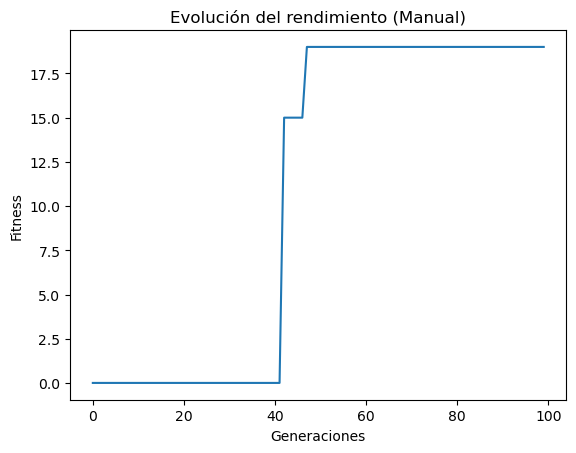

In [2]:
import random
import matplotlib.pyplot as plt

precios = [10, 20, 30, 15, 25]
rendimientos = [2, 5, 9, 3, 6]
max_bonos = [10, 10, 10, 10, 10]
capital = 100

def crear_individuo():
    return [random.randint(0, max_bonos[i]) for i in range(len(precios))]

# Fitness
def fitness(ind):
    costo = sum(ind[i]*precios[i] for i in range(len(ind)))
    rendimiento = sum(ind[i]*rendimientos[i] for i in range(len(ind)))
    return rendimiento if costo <= capital else 0

def seleccion(poblacion):
    return max(random.sample(poblacion, 3), key=fitness)

def cruza(p1, p2):
    punto = random.randint(1, len(p1)-1)
    return p1[:punto] + p2[punto:]

def mutacion(ind):
    i = random.randint(0, len(ind)-1)
    ind[i] = random.randint(0, max_bonos[i])
    return ind

poblacion = [crear_individuo() for _ in range(50)]
historial = []

for gen in range(100):
    nueva = []
    for _ in range(50):
        p1 = seleccion(poblacion)
        p2 = seleccion(poblacion)
        hijo = cruza(p1, p2)
        
        if random.random() < 0.1:
            hijo = mutacion(hijo)
            
        nueva.append(hijo)
    
    poblacion = nueva
    mejor_gen = max(poblacion, key=fitness)
    historial.append(fitness(mejor_gen))

mejor = max(poblacion, key=fitness)
print("Mejor solución:", mejor)
print("Rendimiento máximo:", fitness(mejor))

plt.plot(historial)
plt.title("Evolución del rendimiento (Manual)")
plt.xlabel("Generaciones")
plt.ylabel("Fitness")
plt.show()

In [4]:
!pip install deap

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 4.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [deap]━━━━━━━ 1/2 [deap]


In [5]:
from deap import base, creator, tools, algorithms
import random
import matplotlib.pyplot as plt

precios = [10, 20, 30, 15, 25]
rendimientos = [2, 5, 9, 3, 6]
capital = 100

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

toolbox.register("attr_int", random.randint, 0, 10)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_int, n=5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_individual(ind):
    costo = sum(ind[i]*precios[i] for i in range(len(ind)))
    rendimiento = sum(ind[i]*rendimientos[i] for i in range(len(ind)))
    return (rendimiento if costo <= capital else 0,)

toolbox.register("evaluate", eval_individual)
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutUniformInt, low=0, up=10, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

poblacion = toolbox.population(n=50)

historial = []

for gen in range(100):
    offspring = algorithms.varAnd(poblacion, toolbox, cxpb=0.5, mutpb=0.2)
    fits = list(map(toolbox.evaluate, offspring))
    
    for ind, fit in zip(offspring, fits):
        ind.fitness.values = fit
    
    poblacion = toolbox.select(offspring, k=50)
    mejor = tools.selBest(poblacion, 1)[0]
    historial.append(mejor.fitness.values[0])

mejor = tools.selBest(poblacion, 1)[0]
print("Mejor solución (DEAP):", mejor)
print("Rendimiento máximo:", mejor.fitness.values[0])

plt.plot(historial)
plt.title("Evolución del rendimiento (DEAP)")
plt.xlabel("Generaciones")
plt.ylabel("Fitness")
plt.show()

ModuleNotFoundError: No module named 'deap'